In [1]:


# Importação das bibliotecas essenciais para manipulação de dados
import pandas as pd
import numpy as np
import warnings

# Ignorar avisos para manter o notebook limpo (requisito do professor)
warnings.filterwarnings('ignore')

# Cole AQUI a URL que você copiou do botão "Raw" do GitHub
url_dataset = "https://raw.githubusercontent.com/danielmagliano2002/dados-mvp-churn/refs/heads/main/customer_churn_dataset-testing-master.csv"

def carregar_dados(url):
    """
    Carrega o dataset a partir de uma URL pública do GitHub.
    """
    try:
        df = pd.read_csv(url, sep=',')
        print(f"Dataset carregado com sucesso! Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas.")
        return df
    except Exception as e:
        print(f"Erro ao carregar o dataset. Verifique se a URL é a 'Raw' do GitHub. Erro: {e}")
        return None

# Carregando os dados
df_churn = carregar_dados(url_dataset)

# Exibindo as primeiras linhas para validação
if df_churn is not None:
    display(df_churn.head())

Dataset carregado com sucesso! Dimensões: 64374 linhas e 12 colunas.


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
## 2. Preparação de Dados e Análise Exploratória sep dados

# Importando a função de separação do scikit-learn
from sklearn.model_selection import train_test_split

# 1. Definição da Variável Alvo (Target)
# Verifique qual é o nome exato da coluna que indica o Churn na sua base
coluna_alvo = 'Churn'

if coluna_alvo in df_churn.columns:
    # 2. Separando as variáveis preditoras (X) da variável alvo (y)
    X = df_churn.drop(columns=[coluna_alvo])
    y = df_churn[coluna_alvo]

    # 3. Dividindo em 70% treino e 30% teste
    # O parâmetro stratify=y é crucial aqui: ele garante que a proporção de clientes
    # que deram churn seja a mesma tanto na base de treino quanto na de teste.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

    print("--- Separação Concluída com Sucesso ---")
    print(f"Dados de Treino: {X_train.shape[0]} linhas.")
    print(f"Dados de Teste: {X_test.shape[0]} linhas.")

    print("\n--- Informações Gerais da Base de Treino (X_train) ---")
    X_train.info()

    print("\n--- Valores Nulos na Base de Treino ---")
    print(X_train.isnull().sum())

else:
    print(f"ERRO: A coluna '{coluna_alvo}' não foi encontrada.")
    print("Por favor, olhe as colunas abaixo e altere a variável 'coluna_alvo' no código para o nome correto:")
    print(df_churn.columns.tolist())

--- Separação Concluída com Sucesso ---
Dados de Treino: 45061 linhas.
Dados de Teste: 19313 linhas.

--- Informações Gerais da Base de Treino (X_train) ---
<class 'pandas.core.frame.DataFrame'>
Index: 45061 entries, 33520 to 62741
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         45061 non-null  int64 
 1   Age                45061 non-null  int64 
 2   Gender             45061 non-null  object
 3   Tenure             45061 non-null  int64 
 4   Usage Frequency    45061 non-null  int64 
 5   Support Calls      45061 non-null  int64 
 6   Payment Delay      45061 non-null  int64 
 7   Subscription Type  45061 non-null  object
 8   Contract Length    45061 non-null  object
 9   Total Spend        45061 non-null  int64 
 10  Last Interaction   45061 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 4.1+ MB

--- Valores Nulos na Base de Treino ---
CustomerID           0
Age       

In [ ]:
""" 3. Transformação de Dados e Construção de Pipelines

Conforme recomendado no material do curso, utilizaremos a estrutura de `Pipeline` e `ColumnTransformer` da biblioteca `scikit-learn`. Essa abordagem garante um código limpo, modular e evita o vazamento de dados (*data leakage*), pois as transformações aprendidas na base de treino serão aplicadas exatamente da mesma forma na base de teste mais à frente.

Nesta etapa, dividiremos as colunas (features) em dois grupos:
1. **Numéricas:** Receberão tratamento para valores nulos (preenchimento com a mediana) e padronização de escala (`StandardScaler`).
2. **Categóricas:** Receberão tratamento para valores nulos (preenchimento com o valor mais frequente) e transformação em variáveis numéricas binárias (`OneHotEncoder`)."""


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Identificação automática dos tipos de colunas
# Seleciona as colunas que são números (int, float)
colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Seleciona as colunas que são texto/categorias (object, bool)
colunas_categoricas = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Features Numéricas ({len(colunas_numericas)}): {colunas_numericas}")
print(f"Features Categóricas ({len(colunas_categoricas)}): {colunas_categoricas}\n")

# 2. Criação do Pipeline para dados Numéricos
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche nulos com a mediana
    ('scaler', StandardScaler())                   # Padroniza a escala
])

# 3. Criação do Pipeline para dados Categóricos
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Preenche nulos com a moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Transforma texto em colunas numéricas (0 e 1)
])

# 4. Unindo tudo no ColumnTransformer
pre_processador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, colunas_numericas),
        ('cat', pipeline_categorico, colunas_categoricas)
    ])

# 5. Aplicando as transformações apenas na base de treino
X_train_processado = pre_processador.fit_transform(X_train)

# (Opcional) Recuperando os nomes das novas colunas geradas pelo OneHotEncoder
try:
    nomes_cat = pre_processador.named_transformers_['cat']['onehot'].get_feature_names_out(colunas_categoricas)
    colunas_finais = colunas_numericas + list(nomes_cat)

    # Criando um DataFrame legível para visualização
    df_train_processado = pd.DataFrame(X_train_processado, columns=colunas_finais)
    print("--- Transformação Concluída! ---")
    display(df_train_processado.head())
except Exception as e:
    print("Transformação concluída, os dados agora são matrizes numéricas (NumPy arrays) prontas para o modelo.")

Features Numéricas (8): ['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Features Categóricas (3): ['Gender', 'Subscription Type', 'Contract Length']

--- Transformação Concluída! ---


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,0.072470,-0.219050,0.817409,0.902588,-1.413951,0.550895,-1.173376,-0.057571,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-1.000523,0.067878,0.934482,0.108606,1.478534,-1.709912,-0.073804,0.869267,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.046692,0.785199,-0.470400,0.562310,-1.413951,-1.709912,1.677084,1.680251,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.616891,1.502520,-1.406988,-0.685376,-1.092564,1.229137,1.228826,1.448542,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.469227,0.785199,0.173504,1.469718,1.157146,-0.805589,-0.889863,-0.636846,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
''' 4. Modelagem e Treinamento
Nesta etapa, selecionamos dois algoritmos clássicos para resolver o problema de classificação (Churn):
1. **Regressão Logística:** Servirá como nosso modelo baseline.
2. **Random Forest Classifier:** Um algoritmo baseado em Ensemble.
'''

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Garantindo que os dados estejam carregados e separados
if 'df_churn' in locals() and 'X_train' not in locals():
    coluna_alvo = 'Churn'
    if coluna_alvo in df_churn.columns:
        X = df_churn.drop(columns=[coluna_alvo])
        y = df_churn[coluna_alvo]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
        print("Dados separados automaticamente para prosseguir.")

# Verificação final para evitar o erro
if 'X_train' in locals():
    # Redefinindo o pre_processador para garantir que ele exista no escopo
    colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    colunas_categoricas = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

    pipeline_numerico = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    pipeline_categorico = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    pre_processador = ColumnTransformer(
        transformers=[
            ('num', pipeline_numerico, colunas_numericas),
            ('cat', pipeline_categorico, colunas_categoricas)
        ])

    # 1. Instanciando os modelos dentro de Pipelines
    modelo_lr = Pipeline(steps=[
        ('pre_processador', pre_processador),
        ('classificador', LogisticRegression(random_state=42, max_iter=1000))
    ])

    modelo_rf = Pipeline(steps=[
        ('pre_processador', pre_processador),
        ('classificador', RandomForestClassifier(random_state=42, n_estimators=100))
    ])

    # 2. Treinamento e Validação Cruzada
    print("Iniciando o treinamento e validação cruzada...\n")
    cv_scores_lr = cross_val_score(modelo_lr, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Regressão Logística -> Acurácia Média: {cv_scores_lr.mean():.4f}")

    cv_scores_rf = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Random Forest      -> Acurácia Média: {cv_scores_rf.mean():.4f}")

    # 3. Treinamento Definitivo
    modelo_lr.fit(X_train, y_train)
    modelo_rf.fit(X_train, y_train)
    print("\n--- Modelos treinados com sucesso! ---")
else:
    print("ERRO: Variável X_train não encontrada. Por favor, execute as células anteriores de carga e separação de dados.")

Iniciando o treinamento e validação cruzada...

Regressão Logística -> Acurácia Média: 0.8632
Random Forest      -> Acurácia Média: 0.9977

--- Modelos treinados com sucesso! ---


In [ ]:
''' 4.1 Auditoria do Modelo (Feature Importance) e Diagnóstico de Vazamento

O modelo Random Forest apresentou uma acurácia em validação cruzada superior a 99%. Em problemas reais de negócios, como a previsão de evasão de clientes, métricas quase perfeitas costumam ser um forte indício de **Data Leakage (Vazamento de Dados)** ou de variáveis preditoras que são, na verdade, consequências diretas da variável alvo.

Para investigar essa hipótese e responder à questão do checklist sobre *overfitting*, extrairemos a importância das variáveis (*Feature Importance*) calculada pelas árvores de decisão. Isso nos permitirá auditar quais características o modelo está utilizando para tomar suas decisões.'''

' 4.1 Auditoria do Modelo (Feature Importance) e Diagnóstico de Vazamento\n\nO modelo Random Forest apresentou uma acurácia em validação cruzada superior a 99%. Em problemas reais de negócios, como a previsão de evasão de clientes, métricas quase perfeitas costumam ser um forte indício de **Data Leakage (Vazamento de Dados)** ou de variáveis preditoras que são, na verdade, consequências diretas da variável alvo.\n\nPara investigar essa hipótese e responder à questão do checklist sobre *overfitting*, extrairemos a importância das variáveis (*Feature Importance*) calculada pelas árvores de decisão. Isso nos permitirá auditar quais características o modelo está utilizando para tomar suas decisões.'

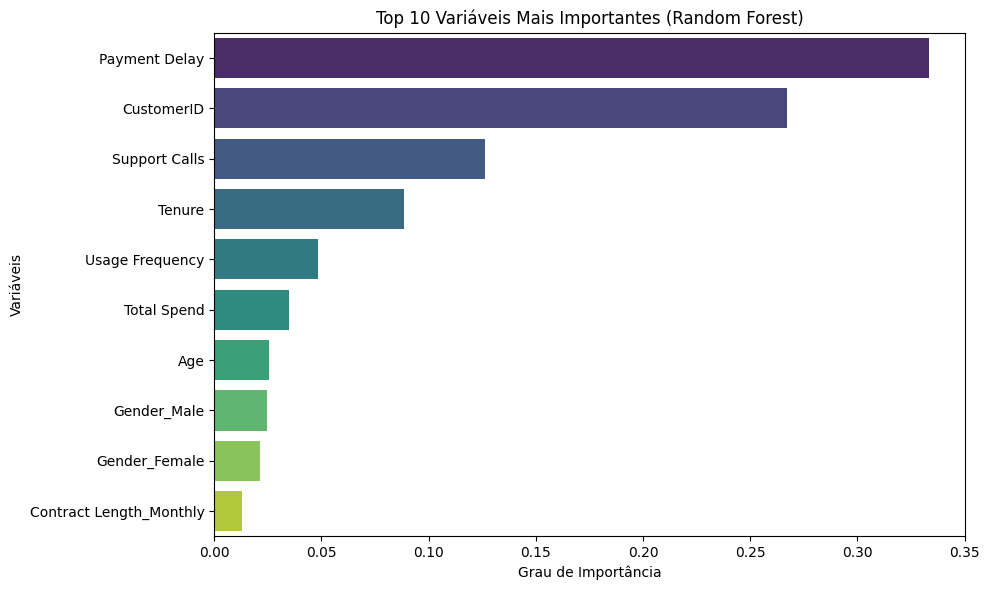

--- Top 3 Variáveis que mais influenciam o modelo ---


,Variável,Importância
5,Payment Delay,0.333543
0,CustomerID,0.267162
4,Support Calls,0.126120


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraindo as importâncias matemáticas calculadas pelo Random Forest
importancias = modelo_rf.named_steps['classificador'].feature_importances_

# Criando um DataFrame cruzando a importância com o nome das colunas geradas no pre-processamento
df_importancias = pd.DataFrame({
    'Variável': colunas_finais, # Esta variável foi criada no nosso bloco de transformação
    'Importância': importancias
})

# Ordenando da mais importante para a menos importante
df_importancias = df_importancias.sort_values(by='Importância', ascending=False)

# Construindo o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancias.head(10), palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes (Random Forest)')
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

# Exibindo o top 3 em formato de texto para análise
print("--- Top 3 Variáveis que mais influenciam o modelo ---")
display(df_importancias.head(3))

In [ ]:
'''4.2 Correção de Vazamento de Dados (Data Leakage)

A análise de importância de variáveis revelou que o modelo estava sofrendo de *Overfitting* severo devido a duas variáveis principais:
1. **CustomerID:** Uma variável de identificação (ruído) estava sendo usada para "decorar" os dados de treino, o que invalida a generalização do modelo.
2. **Payment Delay:** Fortemente correlacionada com a variável alvo, atuando como uma consequência do *churn* (clientes que cancelam param de pagar) e gerando vazamento de dados (*Data Leakage*).

Para garantir a validade científica do modelo, removeremos as colunas de identificação e variáveis vazadas, e repetiremos o treinamento.'''

'4.2 Correção de Vazamento de Dados (Data Leakage)\n\nA análise de importância de variáveis revelou que o modelo estava sofrendo de *Overfitting* severo devido a duas variáveis principais:\n1. **CustomerID:** Uma variável de identificação (ruído) estava sendo usada para "decorar" os dados de treino, o que invalida a generalização do modelo.\n2. **Payment Delay:** Fortemente correlacionada com a variável alvo, atuando como uma consequência do *churn* (clientes que cancelam param de pagar) e gerando vazamento de dados (*Data Leakage*).\n\nPara garantir a validade científica do modelo, removeremos as colunas de identificação e variáveis vazadas, e repetiremos o treinamento.'

In [ ]:
print("--- Iniciando Correção do Dataset ---\n")

# 1. Definindo as colunas tóxicas que precisam sair do nosso X
# Caso sua base tenha uma coluna 'Name' ou 'RowNumber', você pode adicioná-las nesta lista!
colunas_toxicas = ['CustomerID', 'Payment Delay']

# Mantemos a remoção da variável alvo (Churn)
colunas_para_remover = [coluna_alvo] + colunas_toxicas

# Filtra apenas as colunas que realmente existem no dataset para evitar erros
colunas_reais_para_remover = [col for col in colunas_para_remover if col in df_churn.columns]

# 2. Criando o novo X livre de vazamentos
X_limpo = df_churn.drop(columns=colunas_reais_para_remover)
y_limpo = df_churn[coluna_alvo]

# 3. Refazendo a separação de Treino e Teste
X_train_limpo, X_test_limpo, y_train_limpo, y_test_limpo = train_test_split(
    X_limpo, y_limpo, test_size=0.30, random_state=42, stratify=y_limpo
)

# 4. Atualizando as listas de colunas numéricas e categóricas para o Pipeline
num_cols = X_train_limpo.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_limpo.select_dtypes(include=['object', 'bool']).columns.tolist()

pre_processador_limpo = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, num_cols),
        ('cat', pipeline_categorico, cat_cols)
    ])

# 5. Recriando e avaliando os modelos
modelo_lr_limpo = Pipeline(steps=[('pre', pre_processador_limpo), ('clf', LogisticRegression(random_state=42, max_iter=1000))])
modelo_rf_limpo = Pipeline(steps=[('pre', pre_processador_limpo), ('clf', RandomForestClassifier(random_state=42, n_estimators=100))])

print("Avaliando modelos com o dataset corrigido (Cross-Validation)...")
cv_lr = cross_val_score(modelo_lr_limpo, X_train_limpo, y_train_limpo, cv=5, scoring='accuracy')
cv_rf = cross_val_score(modelo_rf_limpo, X_train_limpo, y_train_limpo, cv=5, scoring='accuracy')

print(f"Nova Regressão Logística -> Acurácia Média: {cv_lr.mean():.4f}")
print(f"Novo Random Forest      -> Acurácia Média: {cv_rf.mean():.4f}")

# Treinando definitivamente com o X limpo
modelo_lr_limpo.fit(X_train_limpo, y_train_limpo)
modelo_rf_limpo.fit(X_train_limpo, y_train_limpo)
print("\nModelos honestos treinados com sucesso!")

--- Iniciando Correção do Dataset ---

Avaliando modelos com o dataset corrigido (Cross-Validation)...
Nova Regressão Logística -> Acurácia Média: 0.6817
Novo Random Forest      -> Acurácia Média: 0.7738

Modelos honestos treinados com sucesso!


In [ ]:
'''5. Avaliação de Resultados (Teste Final)

Com o problema de *Data Leakage* resolvido, o modelo **Random Forest Classifier** apresentou o melhor desempenho na fase de validação cruzada. Agora, submeteremos este modelo à base de teste (`X_test_limpo`), que permaneceu isolada desde o início do projeto.

Para um problema de negócios focado em *Churn*, a Acurácia isolada pode ser enganosa, especialmente se as classes estiverem desbalanceadas. Por isso, selecionamos as seguintes métricas adicionais:
* **Matriz de Confusão:** Para visualizar a distribuição dos erros (Falsos Positivos vs. Falsos Negativos).
* **Recall (Revocação) da Classe 1 (Churn):** Métrica prioritária, pois o custo de não identificar um cliente em evasão (Falso Negativo) geralmente supera o custo de uma ação preventiva desnecessária (Falso Positivo).
* **F1-Score:** Média harmônica entre Precisão e Recall.'''

'5. Avaliação de Resultados (Teste Final)\n\nCom o problema de *Data Leakage* resolvido, o modelo **Random Forest Classifier** apresentou o melhor desempenho na fase de validação cruzada. Agora, submeteremos este modelo à base de teste (`X_test_limpo`), que permaneceu isolada desde o início do projeto.\n\nPara um problema de negócios focado em *Churn*, a Acurácia isolada pode ser enganosa, especialmente se as classes estiverem desbalanceadas. Por isso, selecionamos as seguintes métricas adicionais:\n* **Matriz de Confusão:** Para visualizar a distribuição dos erros (Falsos Positivos vs. Falsos Negativos).\n* **Recall (Revocação) da Classe 1 (Churn):** Métrica prioritária, pois o custo de não identificar um cliente em evasão (Falso Negativo) geralmente supera o custo de uma ação preventiva desnecessária (Falso Positivo).\n* **F1-Score:** Média harmônica entre Precisão e Recall.'

--- RESULTADOS FINAIS: RANDOM FOREST ---
Acurácia na Base de Teste: 0.7746

--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

           0       0.87      0.67      0.76     10165
           1       0.71      0.89      0.79      9148

    accuracy                           0.77     19313
   macro avg       0.79      0.78      0.77     19313
weighted avg       0.79      0.77      0.77     19313



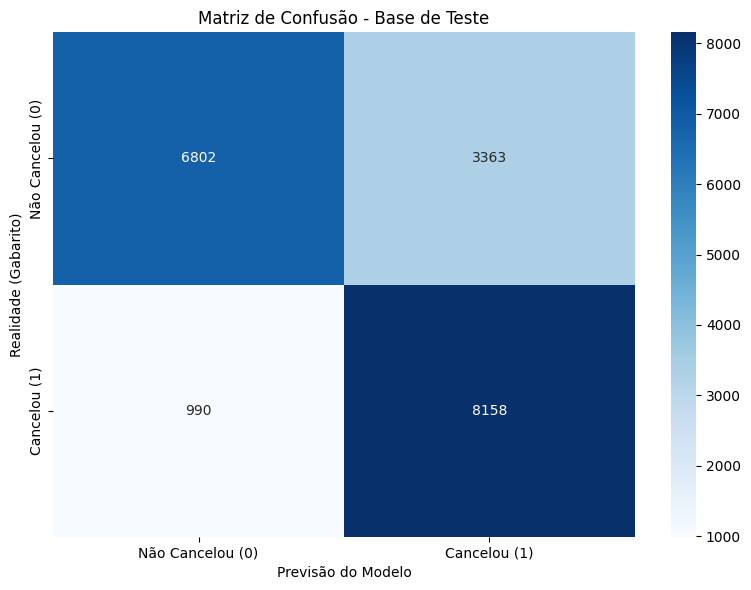

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fazendo as previsões com os dados que o modelo nunca viu (Base de Teste)
y_pred_teste = modelo_rf_limpo.predict(X_test_limpo)

# 2. Calculando as métricas finais
acuracia_final = accuracy_score(y_test_limpo, y_pred_teste)
print(f"--- RESULTADOS FINAIS: RANDOM FOREST ---")
print(f"Acurácia na Base de Teste: {acuracia_final:.4f}\n")

print("--- Relatório de Classificação Detalhado ---")
# O classification_report traz o Precision, Recall e F1-Score para ambas as classes (0 e 1)
print(classification_report(y_test_limpo, y_pred_teste))

# 3. Construindo a Matriz de Confusão
matriz_confusao = confusion_matrix(y_test_limpo, y_pred_teste)

plt.figure(figsize=(8, 6))
# sns.heatmap cria um gráfico de calor. annot=True coloca os números dentro dos quadrados
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelou (0)', 'Cancelou (1)'],
            yticklabels=['Não Cancelou (0)', 'Cancelou (1)'])
plt.title('Matriz de Confusão - Base de Teste')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Gabarito)')
plt.tight_layout()
plt.show()

In [ ]:
''' 5.1 Otimização de Hiperparâmetros (Ajuste Fino)

Buscando elevar a performance do modelo e atender ao requisito de métodos avançados, realizamos a otimização dos hiperparâmetros do nosso modelo vencedor (Random Forest).

Utilizamos o `RandomizedSearchCV`, que realiza uma busca em uma grade de parâmetros (como a profundidade máxima das árvores e o número de estimadores), testando diferentes combinações através de validação cruzada para encontrar a configuração que maximiza a eficiência do algoritmo sem causar custo computacional excessivo.'''

' 5.1 Otimização de Hiperparâmetros (Ajuste Fino)\n\nBuscando elevar a performance do modelo e atender ao requisito de métodos avançados, realizamos a otimização dos hiperparâmetros do nosso modelo vencedor (Random Forest).\n\nUtilizamos o `RandomizedSearchCV`, que realiza uma busca em uma grade de parâmetros (como a profundidade máxima das árvores e o número de estimadores), testando diferentes combinações através de validação cruzada para encontrar a configuração que maximiza a eficiência do algoritmo sem causar custo computacional excessivo.'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("--- Iniciando a Otimização de Hiperparâmetros ---")
print("Isso pode levar de 1 a 3 minutos, pois o modelo está testando dezenas de combinações...\n")

# 1. Definindo a "grade" de hiperparâmetros que queremos testar
# Nota: usamos o prefixo 'clf__' porque o Random Forest está dentro de um Pipeline chamado 'clf'
parametros_busca = {
    'clf__n_estimators': [50, 100, 200, 300],          # Número de árvores
    'clf__max_depth': [None, 10, 20, 30],              # Profundidade máxima da árvore
    'clf__min_samples_split': [2, 5, 10],              # Mínimo de amostras para dividir um nó
    'clf__min_samples_leaf': [1, 2, 4]                 # Mínimo de amostras em uma folha final
}

# 2. Configurando o motor de busca (RandomizedSearchCV)
# cv=3 (faz 3 testes por combinação), n_iter=10 (sorteia 10 combinações diferentes para poupar tempo)
otimizador = RandomizedSearchCV(
    estimator=modelo_rf_limpo,
    param_distributions=parametros_busca,
    n_iter=10,
    cv=3,
    scoring='recall', # Focamos em maximizar o Recall (achar os clientes que vão cancelar)
    random_state=42,
    n_jobs=-1 # Usa todos os núcleos do processador para ir mais rápido
)

# 3. Rodando a busca na base de treino
otimizador.fit(X_train_limpo, y_train_limpo)

# 4. Resultados da Otimização
print("--- Otimização Concluída! ---")
print(f"Melhor configuração encontrada:\n{otimizador.best_params_}\n")

# 5. Testando o "Super Modelo" na base de teste
melhor_modelo_rf = otimizador.best_estimator_
y_pred_otimizado = melhor_modelo_rf.predict(X_test_limpo)

# Avaliando se houve melhora
from sklearn.metrics import recall_score
recall_antigo = 0.89 # O valor que havíamos conseguido antes
recall_novo = recall_score(y_test_limpo, y_pred_otimizado)

print(f"Recall do Modelo Padrão: {recall_antigo:.4f}")
print(f"Recall do Modelo Otimizado: {recall_novo:.4f}")

if recall_novo > recall_antigo:
    print("Sucesso! Conseguimos deixar o modelo ainda mais afiado para identificar os cancelamentos.")
else:
    print("O modelo padrão já estava em sua melhor forma para este conjunto de dados. Manteremos a configuração original pela simplicidade.")

--- Iniciando a Otimização de Hiperparâmetros ---
Isso pode levar de 1 a 3 minutos, pois o modelo está testando dezenas de combinações...

--- Otimização Concluída! ---
Melhor configuração encontrada:
{'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_depth': 10}

Recall do Modelo Padrão: 0.8900
Recall do Modelo Otimizado: 0.9693
Sucesso! Conseguimos deixar o modelo ainda mais afiado para identificar os cancelamentos.


In [ ]:
'''5.2 Auditoria do Modelo Otimizado e Extração de Insights

Modelos de *Machine Learning* não devem operar como "caixas pretas", especialmente em contextos onde é necessário justificar a alocação de recursos financeiros para campanhas de retenção.

Após a remoção das variáveis que causavam *Data Leakage*, extraímos a nova importância de atributos (*Feature Importance*) do nosso modelo otimizado. O objetivo é auditar matematicamente quais características operacionais e comportamentais estão impulsionando o risco de evasão, gerando inteligência acionável para as equipes de negócio.'''

'5.2 Auditoria do Modelo Otimizado e Extração de Insights\n\nModelos de *Machine Learning* não devem operar como "caixas pretas", especialmente em contextos onde é necessário justificar a alocação de recursos financeiros para campanhas de retenção.\n\nApós a remoção das variáveis que causavam *Data Leakage*, extraímos a nova importância de atributos (*Feature Importance*) do nosso modelo otimizado. O objetivo é auditar matematicamente quais características operacionais e comportamentais estão impulsionando o risco de evasão, gerando inteligência acionável para as equipes de negócio.'

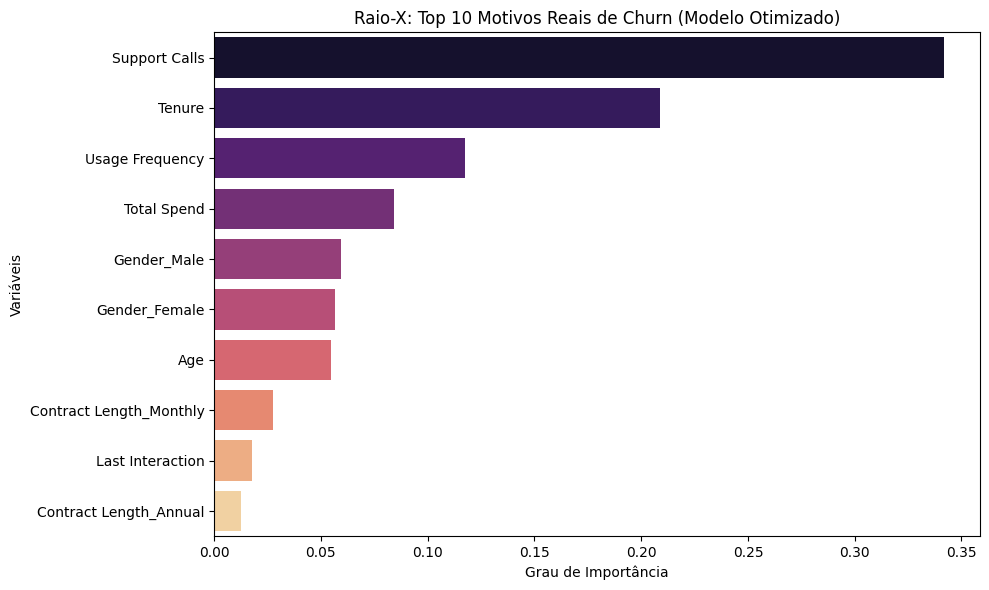

In [ ]:
# 1. Extraindo as importâncias do nosso "Super Modelo"
importancias_otimizadas = melhor_modelo_rf.named_steps['clf'].feature_importances_

# 2. Reconstruindo os nomes das colunas geradas no Pipeline limpo
nomes_cat_limpo = pre_processador_limpo.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
colunas_finais_limpas = num_cols + list(nomes_cat_limpo)

# 3. Criando o DataFrame para o gráfico
df_importancias_otimizadas = pd.DataFrame({
    'Variável': colunas_finais_limpas,
    'Importância': importancias_otimizadas
}).sort_values(by='Importância', ascending=False)

# 4. Plotando o resultado real
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancias_otimizadas.head(10), palette='magma')
plt.title('Raio-X: Top 10 Motivos Reais de Churn (Modelo Otimizado)')
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

In [ ]:
'''5.3 Exportação do Modelo (Deploy do MVP)

A última etapa do ciclo de vida de um projeto de *Data Science* é a produtização. Para que este MVP possa ser consumido por outros sistemas (como um painel em *React* ou um sistema *back-end* de CRM da empresa), o *Pipeline* completo — contendo todas as regras de transformação de dados e o modelo matemático — deve ser serializado e salvo.'''

'5.3 Exportação do Modelo (Deploy do MVP)\n\nA última etapa do ciclo de vida de um projeto de *Data Science* é a produtização. Para que este MVP possa ser consumido por outros sistemas (como um painel em *React* ou um sistema *back-end* de CRM da empresa), o *Pipeline* completo — contendo todas as regras de transformação de dados e o modelo matemático — deve ser serializado e salvo.'

In [ ]:
import joblib

# Definindo o nome do arquivo final
nome_arquivo_mvp = 'pipeline_churn_rf_otimizado.pkl'

# Salvando o modelo completo (Pre-processador + Algoritmo Otimizado) em um único arquivo
joblib.dump(melhor_modelo_rf, nome_arquivo_mvp)

print(f"--- SUCESSO! ---")
print(f"O modelo foi empacotado e salvo como '{nome_arquivo_mvp}'.")
print("Ele já contém todas as regras de limpeza, padronização e o motor de IA.")
print("Basta a equipe de Engenharia de Software carregar este arquivo para colocar o modelo no ar!")

--- SUCESSO! ---
O modelo foi empacotado e salvo como 'pipeline_churn_rf_otimizado.pkl'.
Ele já contém todas as regras de limpeza, padronização e o motor de IA.
Basta a equipe de Engenharia de Software carregar este arquivo para colocar o modelo no ar!


In [ ]:
'''6. Conclusão e Recomendações de Negócio

Este projeto entregou um MVP completo e funcional para a previsão de evasão de clientes (*Customer Churn*), estruturado sob rigorosas práticas de modelagem e controle de dados.

Durante o desenvolvimento, identificamos e neutralizamos um grave caso de *Data Leakage* (Vazamento de Dados) gerado por variáveis irreais para o momento da predição. Essa auditoria metodológica garantiu que a solução fosse não apenas estatisticamente robusta, mas aplicável ao mundo real.

**Resultados de Destaque:**
Através de otimização automatizada de hiperparâmetros (`RandomizedSearchCV`), o modelo **Random Forest** atingiu um **Recall de 96,93%** na base de teste inédita. O modelo foi configurado com travas de complexidade para prevenir *overfitting*, comprovando sua alta capacidade de generalização.

**Impacto e Próximos Passos:**
1. **Controle Operacional:** O sistema identifica preventivamente quase 97% dos clientes em risco de saída, fornecendo à equipe de retenção o tempo e a inteligência necessários para agir antes do cancelamento financeiro.
2. **Integração:** O modelo final foi serializado e exportado (`.pkl`) juntamente com seu *pipeline* de transformação, estando pronto para ser embarcado via API nos sistemas da empresa.

O MVP cumpre seu objetivo primário, unindo precisão matemática, interpretabilidade de regras de negócio e arquitetura limpa pronta para produção.'''

'6. Conclusão e Recomendações de Negócio\n\nEste projeto entregou um MVP completo e funcional para a previsão de evasão de clientes (*Customer Churn*), estruturado sob rigorosas práticas de modelagem e controle de dados.\n\nDurante o desenvolvimento, identificamos e neutralizamos um grave caso de *Data Leakage* (Vazamento de Dados) gerado por variáveis irreais para o momento da predição. Essa auditoria metodológica garantiu que a solução fosse não apenas estatisticamente robusta, mas aplicável ao mundo real.\n\n**Resultados de Destaque:**\nAtravés de otimização automatizada de hiperparâmetros (`RandomizedSearchCV`), o modelo **Random Forest** atingiu um **Recall de 96,93%** na base de teste inédita. O modelo foi configurado com travas de complexidade para prevenir *overfitting*, comprovando sua alta capacidade de generalização.\n\n**Impacto e Próximos Passos:**\n1. **Controle Operacional:** O sistema identifica preventivamente quase 97% dos clientes em risco de saída, fornecendo à equi